In [3]:
import numpy as np
import pandas as pd
import scanpy as sc

from matplotlib import pyplot as plt
import seaborn as sns

import muon as mu

In [61]:
import mofapy2

In [5]:
import os

In [6]:
data_dir = "/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_integration/"

In [7]:
atac = mu.read(os.path.join(data_dir, "atac.h5mu"))

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [8]:
rna = mu.read(os.path.join(data_dir, "rna.h5mu"))

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
rna

MuData object with n_obs × n_vars = 9919 × 26349
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  1 modality
    rna:	9919 x 26349
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

In [10]:
atac

MuData object with n_obs × n_vars = 10042 × 106086
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  1 modality
    atac:	10042 x 106086
      obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'atac', 'celltype_colors', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [11]:
mdata = mu.MuData({
    "rna": rna,
    "atac": atac
})

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [12]:
mdata

MuData object with n_obs × n_vars = 11238 × 132435
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  2 modalities
    rna:	MuData object with n_obs × n_vars = 9919 × 26349
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      1 modality
        rna:	9919 x 26349
          obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
          var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
          uns:	'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
          obsm:	'X_pca', 'X_umap'
          varm:	'PCs'
          obsp:	'connectivities', 'distances'
    atac:	MuData object with n_obs × n_vars = 10042 × 106086
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      1 modality
        atac:	10042 x 106086
          obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden', 'celltype'
          var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
          uns:	'atac', 'celltype_colors', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
          obsm:	'X_lsi', 'X_pca', 'X_umap'
          varm:	'LSI', 'PCs'
          layers:	'counts'
          obsp:	'connectivities', 'distances'

In [13]:
mu.pp.intersect_obs(mdata)

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [14]:
mdata.shape

(8723, 132435)

In [ ]:
#Compare cell type annotation

In [ ]:
#Before performing the integration, we can compare how the cell type annotations in individual modalities match each other.

In [ ]:
#We can calculate a general score that compares those clustering solutions, e.g. the adjusted Rand index.

In [15]:
mdata.mod['rna'].obs.columns

Index(['rna:n_genes_by_counts', 'rna:total_counts', 'rna:total_counts_mt',
       'rna:pct_counts_mt', 'rna:leiden', 'rna:celltype'],
      dtype='object')

In [16]:
mdata.mod['rna'].obs['rna:celltype']

AAACAGCCAATCCCTT-1       CD4+ memory T
AAACAGCCAATGCGCT-1        CD4+ naïve T
AAACAGCCACCAACCG-1        CD8+ naïve T
AAACAGCCAGGATAAC-1        CD4+ naïve T
AAACAGCCAGTAGGTG-1        CD8+ naïve T
                            ...       
TTTGTTGGTGACATGC-1        CD8+ naïve T
TTTGTTGGTGTTAAAC-1        CD8+ naïve T
TTTGTTGGTTAGGATT-1                  NK
TTTGTTGGTTGGTTAG-1       CD4+ memory T
TTTGTTGGTTTGCAGA-1    CD8+ activated T
Name: rna:celltype, Length: 8723, dtype: category
Categories (9, object): ['CD14 mono', 'CD4+ memory T', 'mDC', 'pDC', ..., 'CD4+ naïve T', 'CD16 mono', 'CD8+ activated T', 'NK']

In [17]:
mdata.mod['rna'].obs.columns = [
    col.replace("rna:", "") for col in mdata.mod['rna'].obs.columns
]

In [18]:
print(mdata.mod['rna'].obs.columns)

Index(['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'leiden', 'celltype'],
      dtype='object')


In [19]:
mdata.mod['atac'].obs.columns

Index(['atac:n_genes_by_counts', 'atac:total_counts', 'atac:NS',
       'atac:nucleosome_signal', 'atac:tss_score', 'atac:n_counts',
       'atac:leiden', 'atac:celltype'],
      dtype='object')

In [20]:
mdata.mod['atac'].obs['atac:celltype']

AAACAGCCAATCCCTT-1       CD4+ memory T
AAACAGCCAATGCGCT-1        CD4+ naive T
AAACAGCCACCAACCG-1        Mixed T cell
AAACAGCCAGGATAAC-1        CD4+ naive T
AAACAGCCAGTAGGTG-1        CD8+ naive T
                            ...       
TTTGTTGGTGACATGC-1        CD8+ naive T
TTTGTTGGTGTTAAAC-1        CD8+ naive T
TTTGTTGGTTAGGATT-1                  NK
TTTGTTGGTTGGTTAG-1       CD4+ memory T
TTTGTTGGTTTGCAGA-1    CD8+ activated T
Name: atac:celltype, Length: 8723, dtype: category
Categories (11, object): ['CD14 mono', 'CD4+ memory T', 'Mixed', 'CD8+ naive T', ..., 'Mixed T cell', 'NK', 'Intermediate or CD16 mono', 'MAIT']

In [21]:
mdata.mod['atac'].obs.columns = [
    col.replace("atac:", "") for col in mdata.mod['atac'].obs.columns
]

In [22]:
mdata.mod['atac'].obs.columns

Index(['n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal',
       'tss_score', 'n_counts', 'leiden', 'celltype'],
      dtype='object')

In [23]:
from sklearn.metrics import adjusted_rand_score as ari
ari(mdata.obs['rna:rna:celltype'], mdata.obs['atac:atac:celltype'])

0.7270560020483263

In [ ]:
#We can also look into how those cell type annotations match per cell type

In [24]:
# Calculate total number of cells of respective ATAC celltypes
df_total_atac = (
    mdata.obs.groupby("atac:atac:celltype").
        size().
        reset_index(name="n_total").
        set_index("atac:atac:celltype")
)

/var/folders/wt/z___z_1n7mb_ywtv9xc9qbgw0000gn/T/ipykernel_19203/1311962943.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata.obs.groupby("atac:atac:celltype").


In [25]:
df_total_atac

,n_total
atac:atac:celltype,
CD14 mono,2957
CD4+ memory T,1426
Mixed,1
CD8+ naive T,1307
CD4+ naive T,1247
CD8+ activated T,736
Naive B,15
Mixed T cell,368
NK,434


In [26]:
# Calculate total number of cells of respective rna celltypes
df_total_rna = (
    mdata.obs.groupby("rna:rna:celltype").
        size().
        reset_index(name="n_total").
        set_index("rna:rna:celltype")
)

/var/folders/wt/z___z_1n7mb_ywtv9xc9qbgw0000gn/T/ipykernel_19203/460368229.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata.obs.groupby("rna:rna:celltype").


In [27]:
df_total_rna

,n_total
rna:rna:celltype,
CD14 mono,2089
CD4+ memory T,1621
mDC,176
pDC,92
CD8+ naïve T,1399
CD4+ naïve T,1338
CD16 mono,853
CD8+ activated T,699
NK,456


In [28]:
mdata.obs['rna_celltype'] = mdata.mod['rna'].obs['celltype']
mdata.obs['atac_celltype'] = mdata.mod['atac'].obs['celltype']

In [30]:
# Calculate number of cells for each pair of RNA-ATAC celltype annotation
df_no_of_cell_by_type = (
    mdata.obs.groupby(["atac_celltype", "rna_celltype"]).
        size().
        reset_index(name="n").
        set_index("atac_celltype").
        join(df_total_rna).
        reset_index()
)

/var/folders/wt/z___z_1n7mb_ywtv9xc9qbgw0000gn/T/ipykernel_19203/3811333491.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata.obs.groupby(["atac_celltype", "rna_celltype"]).


In [31]:
mdata.mod['atac'].obs.columns

Index(['n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal',
       'tss_score', 'n_counts', 'leiden', 'celltype'],
      dtype='object')

In [32]:
mdata.mod['rna'].obs.columns

Index(['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'leiden', 'celltype'],
      dtype='object')

In [33]:
df_no_of_cell_by_type

,atac_celltype,rna_celltype,n,n_total
0,CD14 mono,CD14 mono,2067,2089.0
1,CD14 mono,CD4+ memory T,0,2089.0
2,CD14 mono,mDC,41,2089.0
3,CD14 mono,pDC,0,2089.0
4,CD14 mono,CD8+ naïve T,0,2089.0
...,...,...,...,...
94,MAIT,CD8+ naïve T,0,NaN
95,MAIT,CD4+ naïve T,0,NaN
96,MAIT,CD16 mono,0,NaN
97,MAIT,CD8+ activated T,1,NaN


In [37]:
# Calculate a fraction of cells of each RNA celltype (n)
# for each ATAC celltype (/ n_total)
df_frac = df_no_of_cell_by_type.assign(frac = lambda x: x.n / x.n_total)

In [34]:
#We can now make a wide table and visualise it with a heatmap.



In [38]:
df_wide = df_frac.set_index("atac_celltype").pivot(columns="rna_celltype", values="frac")


<Axes: xlabel='rna_celltype', ylabel='atac_celltype'>

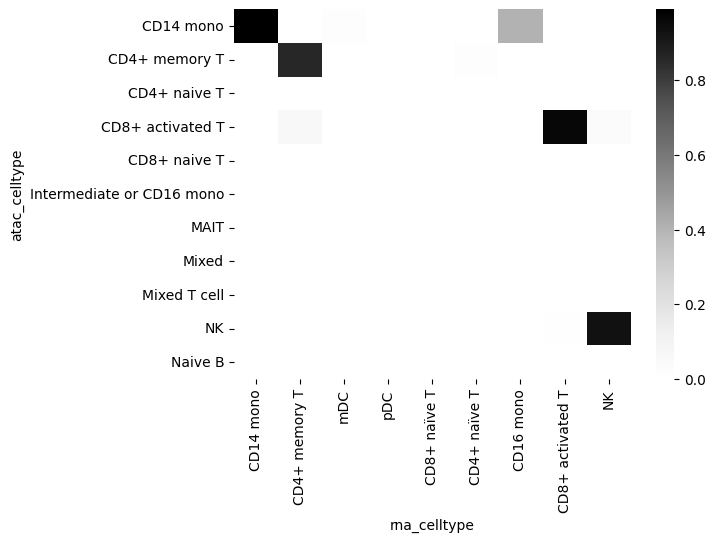

In [39]:
import seaborn as sns
sns.heatmap(df_wide, cmap="Greys")

In [ ]:
#Rerun ATAC and RNA to check why cell types not highly reproducible

In [40]:
#Perform integration
#We will now run multi-omic factor analysis — a group factor analysis method that will allow us to learn an interpretable latent space jointly on both modalities. Intuitively, it can be viewed as a generalisation of PCA for multi-omics data. More information about this method can be found on the MOFA website.

#The time required to train the model depends on the number of cells and features as well as on hardware specs. For the current dataset, it takes 4 minutes on the GeForce RTX 2080 Ti NVIDIA card. Only highly variable features are used by default.



In [41]:
#mdata.mod['rna'].X = mdata.mod['rna'].layers['counts'].copy()

In [42]:
mdata.mod

MuData
├─ rna MuData [shared obs] (8723 × 26349)
│  └─ rna AnnData (8723 x 26349)
└─ atac MuData [shared obs] (8723 × 106086)
   └─ atac AnnData (8723 x 106086)

In [43]:
print(type(mdata.mod['rna'].X))
print(type(mdata.mod['atac'].X))

<class 'NoneType'>
<class 'NoneType'>


In [44]:
mdata.mod.keys()

dict_keys(['rna', 'atac'])

In [ ]:
#You have MuData inside MuData (nested MuData)

In [45]:
# unwrap
rna = mdata.mod['rna'].mod['rna']
atac = mdata.mod['atac'].mod['atac']

# rebuild clean MuData
mdata = mu.MuData({
    "rna": rna,
    "atac": atac
})

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [46]:
mdata

MuData object with n_obs × n_vars = 8723 × 132435
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  2 modalities
    rna:	8723 x 26349
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	8723 x 106086
      obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'atac', 'celltype_colors', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [47]:
mu.pp.intersect_obs(mdata)

/Users/siddharthadas/miniconda3/envs/multiome_dl/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [48]:
mdata.mod['rna'].X = mdata.mod['rna'].X.copy()

In [49]:
mdata.mod['atac'].X = mdata.mod['atac'].X.copy()

In [62]:
mu.tl.mofa(mdata, outfile="/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_integration/models/pbmc10k_rna_atac.hdf5")



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=8723 samples and D=3026 features...
Loaded view='atac' group='group1' with N=8723 samples and D=19430 features...



Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
L

In [63]:
mdata

MuData object with n_obs × n_vars = 8723 × 132435
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa'
  obsm:	'X_mofa'
  varm:	'LFs'
  2 modalities
    rna:	8723 x 26349
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	8723 x 106086
      obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'atac', 'celltype_colors', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [ ]:
#After the training, the embedding will be added to the obsm slot of the mdata:

In [64]:
mdata.obsm.keys()

KeysView(MuAxisArrays with keys: rna, atac, X_mofa)

In [54]:
#We can directly use it for plotting with mu.pl or sc.pl plotting functions — mdata has both .obs and .obsm slots that are needed for plotting with the latter one.

In [65]:
# Copy colours that were defined previously
mdata.uns = mdata.uns or dict()
mdata.uns['rna:celltype_colors'] = mdata['rna'].uns['celltype_colors']
mdata.uns['atac:celltype_colors'] = mdata['atac'].uns['celltype_colors']

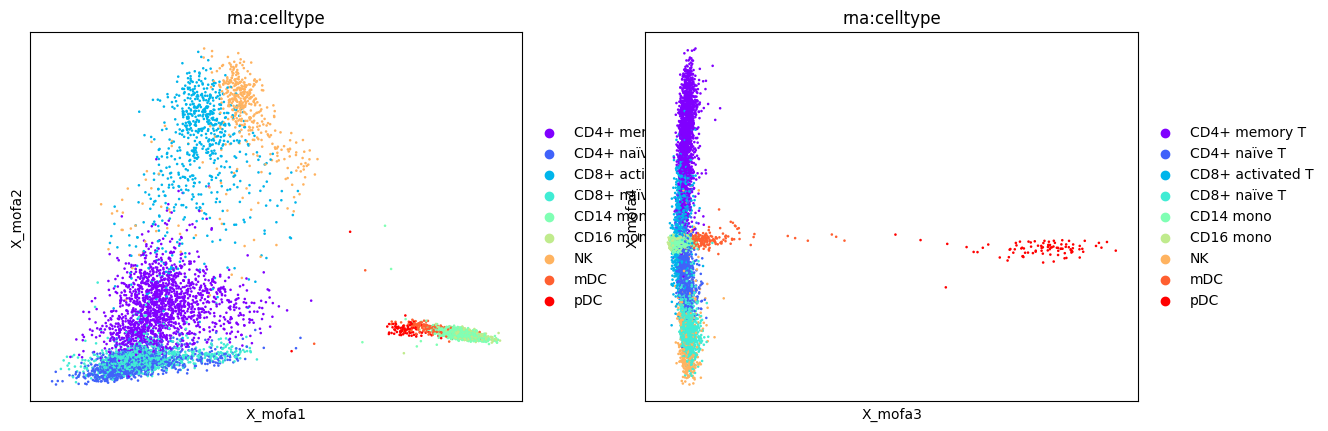

In [66]:
mu.pl.mofa(mdata, color="rna:celltype", components=["1,2", "3,4"])
# 'rna:celltype' is a column in mdata.obs
# derived from the 'celltype' column of mdata['rna'].obs

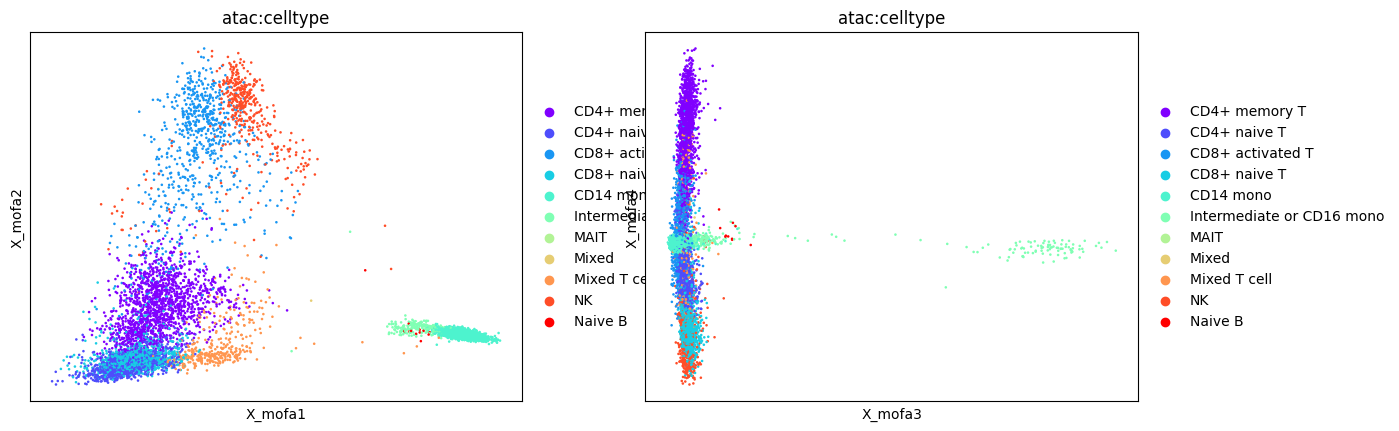

In [67]:
mu.pl.mofa(mdata, color="atac:celltype", components=["1,2", "3,4"])
# 'atac:celltype' is a column in mdata.obs
# derived from the 'celltype' column of mdata['atac'].obs

In [ ]:
#We can then use this embedding not only to compare cell type annotation performed individually on each modality but also to annotate cell types based on both omics jointly.

In [ ]:
#To visualise all the factors together, we’ll use a non-linear dimensionality reduction method such as UMAP to display the embedding in 2D:

In [68]:
sc.pp.neighbors(mdata, use_rep="X_mofa")
sc.tl.umap(mdata)

In [69]:
sc.tl.umap(mdata, min_dist=.2, spread=1., random_state=10)

In [ ]:
#For instance, we can then visualise how cell type annotations performed on individual modalities correspond to this 2D projection of the joint MOFA embeddings

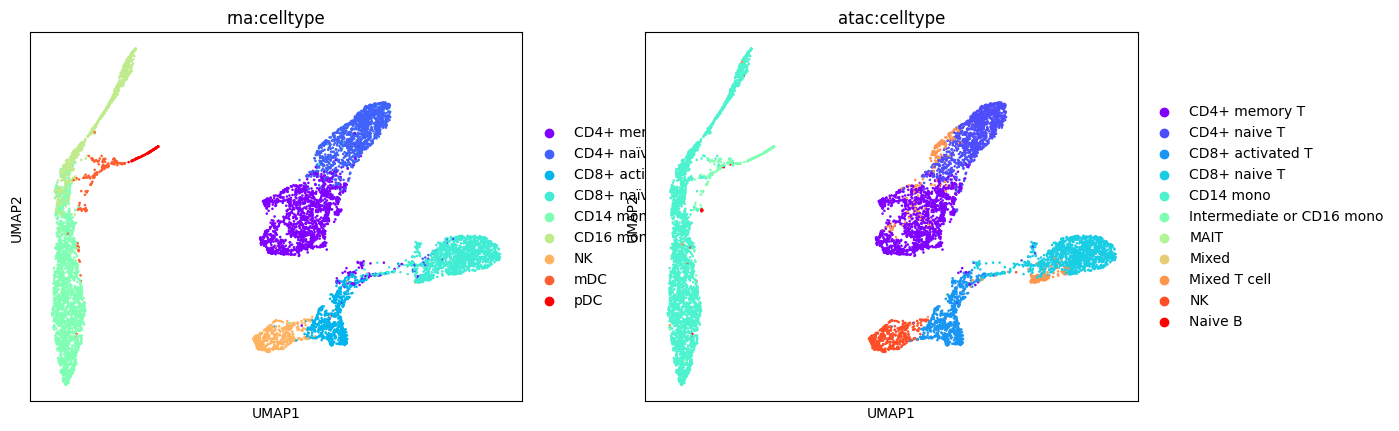

In [70]:
sc.pl.umap(mdata, color=["rna:celltype", "atac:celltype"])

In [ ]:
#Conventional clustering can now be performed based on the MOFA embeddings and also can be visualised on the same UMAP:

In [71]:
sc.tl.leiden(mdata, key_added='leiden_joint')

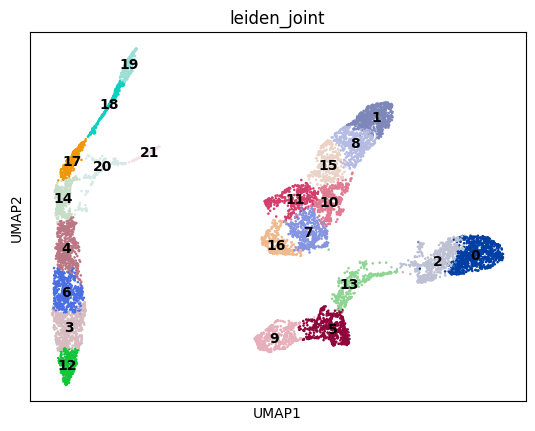

In [72]:
sc.pl.umap(mdata, color="leiden_joint", legend_loc='on data')

In [ ]:
#Individual features from modalities are also available when plotting embeddings:



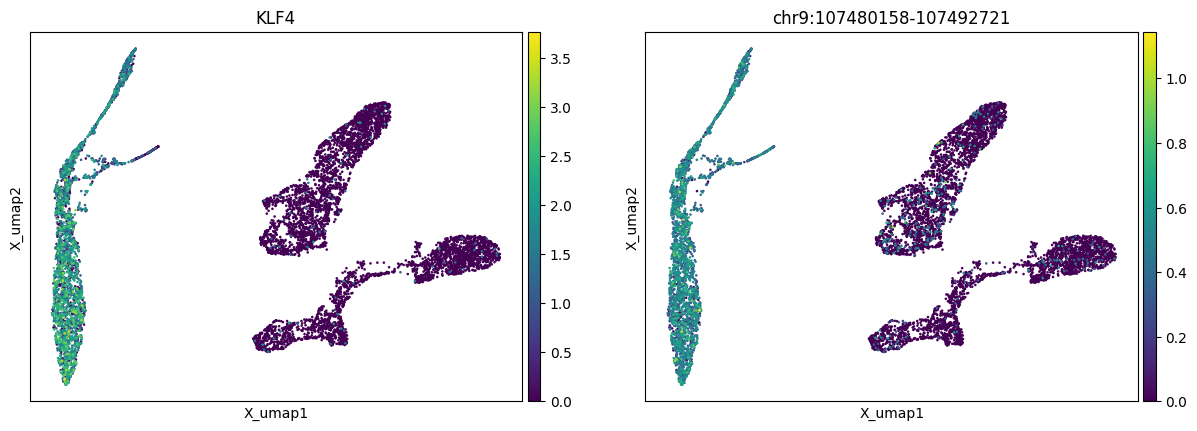

In [73]:
mu.pl.umap(mdata, color=["KLF4", "chr9:107480158-107492721"])

In [ ]:
#We can also generate custom plots with matplotlib and seaborn

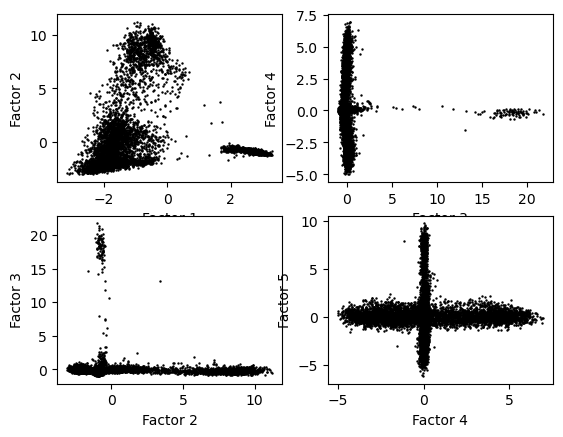

In [89]:
df = pd.DataFrame(mdata.obsm["X_mofa"])
df.columns = [f"Factor {i+1}" for i in range(df.shape[1])]

plot_scatter = lambda i, ax: sns.scatterplot(data=df, x=f"Factor {i+1}", y=f"Factor {i+2}", color="black", linewidth=0, s=3, ax=ax)

fig, axes = plt.subplots(2, 2)
for i in range(4):
    plot_scatter(i, axes[i%2][i//2])

In [ ]:
#Annotate cell types
#We will now define cell types based on both omics.



In [74]:
mdata['rna'].obs['leiden_joint'] = mdata.obs.leiden_joint
mdata['atac'].obs['leiden_joint'] = mdata.obs.leiden_joint

In [ ]:
#Ranking genes and peaks

In [75]:
sc.tl.rank_genes_groups(mdata['rna'], 'leiden_joint', method='t-test_overestim_var')

In [76]:
from muon import atac as ac
ac.tl.rank_peaks_groups(mdata['atac'], 'leiden_joint', method='t-test_overestim_var')

In [ ]:
#Listing differentially expressed genes and differentially accessible peaks

In [77]:
result = {}
result['rna'] = mdata['rna'].uns['rank_genes_groups']
result['rna']['genes'] = result['rna']['names']
result['atac'] = mdata['atac'].uns['rank_genes_groups']

In [78]:
groups = result['rna']['names'].dtype.names
pd.set_option("display.max_columns", 200)
pd.DataFrame(
    {mod + ':' + group + '_' + key[:1]: result[mod][key][group][:10]
    for group in groups for key in ['names', 'genes', 'pvals']
    for mod in mdata.mod.keys()})

,rna:0_n,atac:0_n,rna:0_g,atac:0_g,rna:0_p,atac:0_p,rna:1_n,atac:1_n,rna:1_g,atac:1_g,rna:1_p,atac:1_p,rna:2_n,atac:2_n,rna:2_g,atac:2_g,rna:2_p,atac:2_p,rna:3_n,atac:3_n,rna:3_g,atac:3_g,rna:3_p,atac:3_p,rna:4_n,atac:4_n,rna:4_g,atac:4_g,rna:4_p,atac:4_p,rna:5_n,atac:5_n,rna:5_g,atac:5_g,rna:5_p,atac:5_p,rna:6_n,atac:6_n,rna:6_g,atac:6_g,rna:6_p,atac:6_p,rna:7_n,atac:7_n,rna:7_g,atac:7_g,rna:7_p,atac:7_p,rna:8_n,atac:8_n,rna:8_g,atac:8_g,rna:8_p,atac:8_p,rna:9_n,atac:9_n,rna:9_g,atac:9_g,rna:9_p,atac:9_p,rna:10_n,atac:10_n,rna:10_g,atac:10_g,rna:10_p,atac:10_p,rna:11_n,atac:11_n,rna:11_g,atac:11_g,rna:11_p,atac:11_p,rna:12_n,atac:12_n,rna:12_g,atac:12_g,rna:12_p,atac:12_p,rna:13_n,atac:13_n,rna:13_g,atac:13_g,rna:13_p,atac:13_p,rna:14_n,atac:14_n,rna:14_g,atac:14_g,rna:14_p,atac:14_p,rna:15_n,atac:15_n,rna:15_g,atac:15_g,rna:15_p,atac:15_p,rna:16_n,atac:16_n,rna:16_g,atac:16_g,rna:16_p,atac:16_p,rna:17_n,atac:17_n,rna:17_g,atac:17_g,rna:17_p,atac:17_p,rna:18_n,atac:18_n,rna:18_g,atac:18_g,rna:18_p,atac:18_p,rna:19_n,atac:19_n,rna:19_g,atac:19_g,rna:19_p,atac:19_p,rna:20_n,atac:20_n,rna:20_g,atac:20_g,rna:20_p,atac:20_p,rna:21_n,atac:21_n,rna:21_g,atac:21_g,rna:21_p,atac:21_p
0,BACH2,chr2:86783559-86792275,BACH2,CD8A,5.474803e-196,2.143712e-179,FHIT,chr14:99255246-99275454,FHIT,"BCL11B, AL109767.1",7.363730e-129,4.456216e-51,BACH2,chr2:86783559-86792275,BACH2,CD8A,8.719254e-126,1.771949e-72,VCAN,chr9:107480158-107492721,VCAN,KLF4,4.611607e-208,1.595768e-86,PLXDC2,chr9:107480158-107492721,PLXDC2,KLF4,3.146445e-134,1.504998e-85,CCL5,chr1:184386243-184389335,CCL5,"C1orf21, AL445228.2",1.205616e-316,4.432388e-101,VCAN,chr9:107480158-107492721,VCAN,KLF4,1.170771e-159,1.867120e-79,INPP4B,chr5:756911-759750,INPP4B,"ZDHHC11B, AC026740.3",1.743787e-99,1.010222e-48,BACH2,chr14:99255246-99275454,BACH2,"BCL11B, AL109767.1",1.272842e-75,1.287198e-39,GNLY,chr17:83076201-83103570,GNLY,"METRNL, AC130371.2",1.734802e-311,2.885907e-110,INPP4B,chr20:13219846-13222495,INPP4B,ISM1,1.912383e-79,1.772661e-21,IL32,chr14:22536559-22563070,IL32,"TRAJ7, TRAJ6, TRAJ5, TRAJ4, TRAJ3, TRAJ2, TRAJ...",5.934946e-43,4.551817e-33,VCAN,chr9:107480158-107492721,VCAN,KLF4,1.180963e-128,4.022487e-45,CCL5,chr2:86783559-86792275,CCL5,CD8A,9.123203e-78,4.579764e-47,SLC8A1,chr9:107480158-107492721,SLC8A1,KLF4,7.187238e-90,1.337046e-48,MALAT1,chr14:22536559-22563070,MALAT1,"TRAJ7, TRAJ6, TRAJ5, TRAJ4, TRAJ3, TRAJ2, TRAJ...",8.423188e-42,1.474031e-22,RORA,chr6:161076038-161077022,RORA,"MAP3K4, AL139393.3",5.903869e-73,1.499740e-40,HLA-DRA,chr9:107480158-107492721,HLA-DRA,KLF4,1.073181e-78,6.125044e-35,TCF7L2,chr2:16653069-16660704,TCF7L2,FAM49A,6.719578e-106,3.089201e-34,FCGR3A,chr2:16653069-16660704,FCGR3A,FAM49A,1.126401e-171,2.614834e-34,HLA-DQA1,chr10:70493034-70495432,HLA-DQA1,PALD1,4.340893e-85,4.712315e-21,TCF4,chr20:43681305-43682881,TCF4,MYBL2,2.197536e-121,9.315716e-33
1,NELL2,chr12:10552886-10555668,NELL2,LINC02446,8.949459e-196,3.563758e-147,LEF1,chr14:99181080-99219442,LEF1,"BCL11B, AL162151.1",1.301657e-109,1.537078e-48,LEF1,chr11:66311352-66319301,LEF1,"CD248, AP001107.3",1.099686e-107,4.002131e-59,PLXDC2,chr22:38950570-38958424,PLXDC2,APOBEC3A,3.056052e-174,2.026647e-66,TYMP,chr6:44057321-44060655,TYMP,"AL109615.2, AL109615.3",4.065532e-125,2.165024e-68,NKG7,chr4:6198055-6202103,NKG7,"JAKMIP1, C4orf50",4.844261e-290,5.106944e-98,PLXDC2,chr6:41268623-41279829,PLXDC2,TREM1,7.868229e-147,1.361845e-67,ITGB1,chr21:45223468-45225379,ITGB1,"LINC00334, ADARB1",2.890336e-99,5.354306e-40,FHIT,chr14:99223600-99254668,FHIT,"BCL11B, AL109767.1",2.250865e-73,9.185620e-36,PRF1,chr1:184386243-184389335,PRF1,"C1orf21, AL445228.2",4.399765e-226,1.404186e-79,ANK3,chr12:22332848-22336188,ANK3,ST8SIA1,6.514543e-76,3.017655e-21,LTB,chr10:33135632-33141841,LTB,IATPR,4.298041e-43,1.066680e-25,CSF3R,chr6:41268623-41279829,CSF3R,TREM1,7.506417e-125,5.909106e-42,IFNG-AS1,chr1:24909406-24919504,IFNG-AS1,RUNX3,2.917153e-47,9.914622e-29,TYMP,chr1:182143071-182150314,TYMP,"LINC01344, A

In [ ]:
Assigning cell type labels
0,1, 5,8,20 are CD4+ memory T
6 and 3 are CD4+ naive T
mDC is okay as cluster 18
9 is NK
20 is pDC
2 and 4 is classical mono
15 is classical mono
10 is intermediate mono
17 is non-classical mono
16 is non-classical mono
7 is CD4+ T memory
11 is CD8+ transitional effector T
12 is classical mono
14 maybe MAIT 
13 is like mono
19 is not sure

In [79]:
new_cluster_names = {
    "0": "CD4+ memory T", "8": "CD4+ memory T",
    "1": "CD4+ memory T", "6": "CD4+ naive T", "17": "non-classical mono",
    "2": "classical mono", "5": "CD4+ memory T", "20": "CD4+ memory T",
    "10": "intermediate mono", "11": "CD8+ transitional effector T",
    "19": "Not sure", "12": "classical mono",

    "16": "non-classical mono", "15": "classical mono",

    "3": "CD4+ naive T", "7": "CD4+ memory T", "9": "NK", "14": "MAIT",
    "4": "classical mono", "13": "like mono",
    "18": "mDC",
}

mdata.obs['celltype'] = mdata.obs.leiden_joint.astype("str")
mdata.obs.celltype = mdata.obs.celltype.map(new_cluster_names).astype("category")

In [80]:
mdata.obs['celltype'].value_counts()

celltype
CD4+ memory T                   3031
classical mono                  1751
CD4+ naive T                    1065
non-classical mono               554
NK                               413
intermediate mono                359
CD8+ transitional effector T     355
like mono                        329
MAIT                             325
mDC                              244
Not sure                         205
Name: count, dtype: int64

In [82]:
mdata.obs.celltype.cat.reorder_categories([
    'CD4+ naive T', 'CD4+ memory T',
    'CD8+ transitional effector T',
    'MAIT', 'NK',
    'classical mono', 'intermediate mono', 'non-classical mono', 'like mono',
    'mDC', 'Not sure'], ordered=True)

AAACAGCCAATCCCTT-1                       like mono
AAACAGCCAATGCGCT-1                   CD4+ memory T
AAACAGCCACCAACCG-1                  classical mono
AAACAGCCAGGATAAC-1                   CD4+ memory T
AAACAGCCAGTAGGTG-1                  classical mono
                                  ...             
TTTGTTGGTGACATGC-1                  classical mono
TTTGTTGGTGTTAAAC-1                   CD4+ memory T
TTTGTTGGTTAGGATT-1                              NK
TTTGTTGGTTGGTTAG-1    CD8+ transitional effector T
TTTGTTGGTTTGCAGA-1                       like mono
Name: celltype, Length: 8723, dtype: category
Categories (11, object): ['CD4+ naive T' < 'CD4+ memory T' < 'CD8+ transitional effector T' < 'MAIT' ... 'non-classical mono' < 'like mono' < 'mDC' < 'Not sure']

In [83]:
import matplotlib
import matplotlib.pyplot as plt

cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(mdata.obs.celltype.cat.categories)))

mdata.uns["celltype_colors"] = list(map(matplotlib.colors.to_hex, colors))

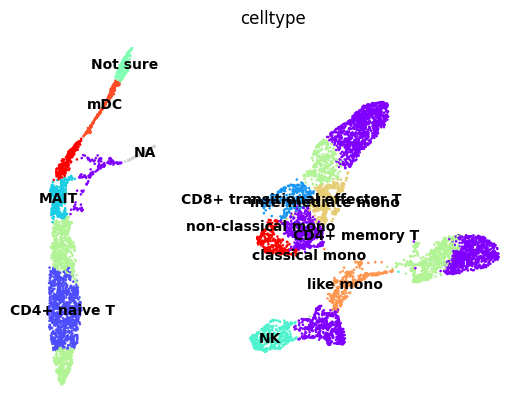

In [84]:
mu.pl.umap(mdata, color="celltype", legend_loc="on data", frameon=False)


In [85]:
#Visualising markers

In [86]:
mdata['rna'].obs['celltype_joint'] = mdata.obs.celltype
mdata['atac'].obs['celltype_joint'] = mdata.obs.celltype

In [87]:
marker_genes = [
    'IL7R', 'TRAC', 'GATA3',                                # CD4+ T
    'LEF1', 'FHIT', 'RORA', 'ITGB1',                        # naïve/memory
    'CD8A', 'CD8B', 'CD248', 'CCL5',                        # CD8+ T
    'GZMH', 'GZMK',                                         # cytotoxic/transitional effector T cells
    'KLRB1', 'SLC4A10',                                     # MAIT
    'IL32',                                                 # T/NK
    'GNLY', 'NKG7',                                         # NK
    'CD79A', 'MS4A1', 'IGHD', 'IGHM', 'IL4R', 'TNFRSF13C',  # B
    'KLF4', 'LYZ', 'S100A8', 'ITGAM', 'CD14',               # mono
    'DPYD', 'ITGAM',                                        # classical/intermediate/non-classical mono
    'FCGR3A', 'MS4A7', 'CST3',                              # non-classical mono
    'CLEC10A', 'IRF8', 'TCF4'                               # DC
]

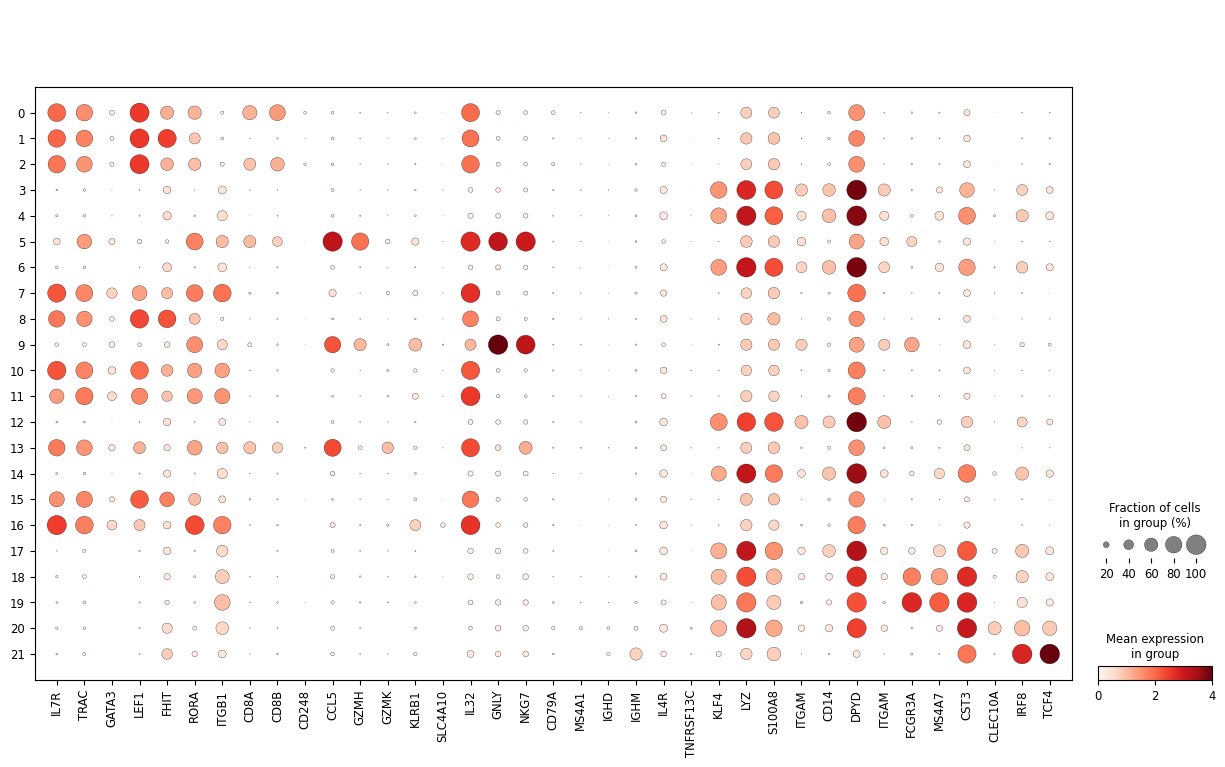

In [88]:
sc.pl.dotplot(mdata['rna'], marker_genes, 'leiden_joint')

In [89]:
marker_peaks = [
    'chr14:99255246-99275454', 'chr10:33135632-33141841',                              # T/NK
    'chr1:1210271-1220028',                                                            # memory T/NK
    'chr2:86783559-86792275',                                                          # CD8+ T/NK
    'chr12:10552886-10555668',                                                         # naïve CD8+ T
    'chr11:114072228-114076352',                                                       # MAIT/NK
    'chr5:150385442-150415310',                                                        # B and mono (CD74)
    'chr22:41931503-41942227', 'chr22:41917087-41929835', 'chr6:167111604-167115345',  # B
    'chr9:107480158-107492721', 'chr5:1476663-1483241',                                # mono
    'chr10:75399596-75404660', 'chr1:220876295-220883526',                             # mDC
    'chr17:81425658-81431769', 'chr7:98641522-98642532',                               # pDC
]

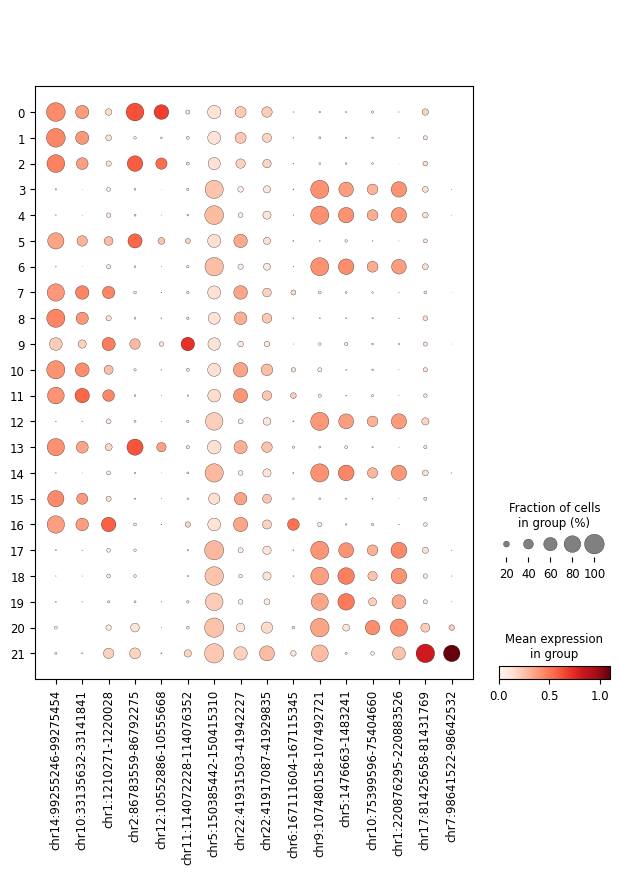

In [90]:
sc.pl.dotplot(mdata['atac'], marker_peaks, 'leiden_joint')

In [91]:
mdata.write("/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_integration/pbmc10k.h5mu")

In [ ]:
# Link to tutorial - https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/brain3k/1-Processing-and-Integration.html